# EDA

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from utils import get_null_info, plot_features_against_target, target_info

In [2]:
RANDOM_SEED = 42
TARGET_NAME = 'price'

In [3]:
df = pd.read_csv(Path('data') / '1 Housing.csv', usecols=['area', 'bedrooms', 'bathrooms', 'price'])
df

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1
...,...,...,...,...
540,1820000,3000,2,1
541,1767150,2400,3,1
542,1750000,3620,2,1
543,1750000,2910,3,1


In [4]:
# it's sorted by price!
# 2. Generate a random permutation of indices to shuffle rows together
rng = np.random.default_rng(seed=RANDOM_SEED)
shuffle_idx = rng.permutation(len(df))
df = df.iloc[shuffle_idx]
df

,price,area,bedrooms,bathrooms
138,5740000,5000,3,1
80,6629000,6000,3,1
358,3745000,3480,2,1
132,5810000,5200,3,1
98,6293000,6600,3,2
...,...,...,...,...
113,6083000,9620,3,1
437,3290000,5880,3,1
491,2835000,2640,2,1
526,2310000,3180,2,1


In [5]:
duplicates_df = df[df.duplicated()]
display(duplicates_df)

,price,area,bedrooms,bathrooms
279,4270000,6360,2,1
49,7420000,7440,3,2
102,6195000,5500,3,2
366,3675000,3630,2,1


In [6]:
df = df.drop(index=duplicates_df.index)

In [7]:
train_data_rows = int(np.ceil(len(df)*0.8))
df_train = df[:train_data_rows]
df_test = df[:len(df)-train_data_rows]

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (433, 4)
Test shape: (108, 4)


In [8]:
df_train.to_csv(Path('data') / '2 train_raw.csv')
df_test.to_csv(Path('data') / '2 test_raw.csv')

In [9]:
df_train.describe()

,price,area,bedrooms,bathrooms
count,4.330000e+02,433.000000,433.000000,433.000000
mean,4.739184e+06,5065.886836,2.937644,1.272517
std,1.849676e+06,2081.877717,0.741177,0.480747
min,1.750000e+06,1650.000000,1.000000,1.000000
25%,3.465000e+06,3570.000000,2.000000,1.000000
50%,4.375000e+06,4500.000000,3.000000,1.000000
75%,5.600000e+06,6300.000000,3.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,3.000000


In [10]:
df_train.dtypes

price        int64
area         int64
bedrooms     int64
bathrooms    int64
dtype: object

In [11]:
df_test.dtypes

price        int64
area         int64
bedrooms     int64
bathrooms    int64
dtype: object

In [12]:
type_dict = {'area': float, TARGET_NAME: float}

df_train = df_train.astype(type_dict)
df_test = df_test.astype(type_dict)

In [13]:
df_nulls = get_null_info(df_train)
df_nulls

No missing values are found in the dataframe


[]

In [14]:
df_nulls = get_null_info(df_test)
df_nulls

No missing values are found in the dataframe


[]

Unique target values:


,counts,%
price,,
3500000.0,17,0.04
4900000.0,10,0.02
4200000.0,10,0.02
5600000.0,8,0.02
3150000.0,8,0.02
...,...,...
6125000.0,1,0.00
2961000.0,1,0.00
3234000.0,1,0.00


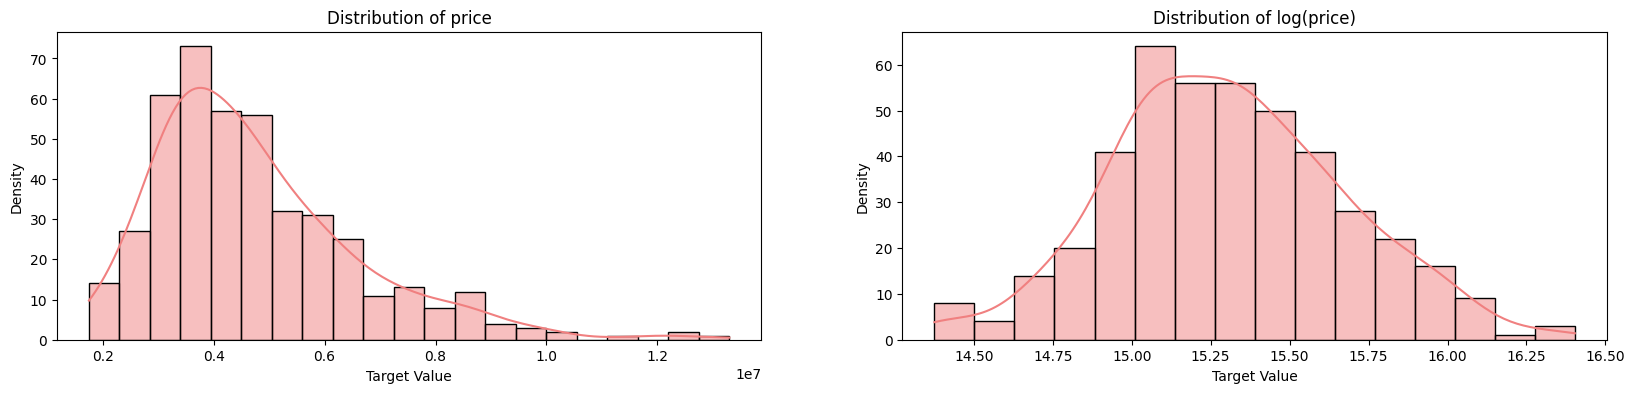

In [15]:
target_info(df_train, TARGET_NAME, "log")

target is normal, right skewed, should be transformed

In [16]:
df_train.loc[:, TARGET_NAME] = np.log(df_train[TARGET_NAME])
df_test.loc[:, TARGET_NAME] = np.log(df_test[TARGET_NAME])

- area (continuous) - normal; right-skewed, log transformation helps, doesn't look too linear
- bedrooms - discrete; shouldn't be transformed
- bathrooms - discrete; shouldn't be transformed

Generating diagnostic profiling for: area


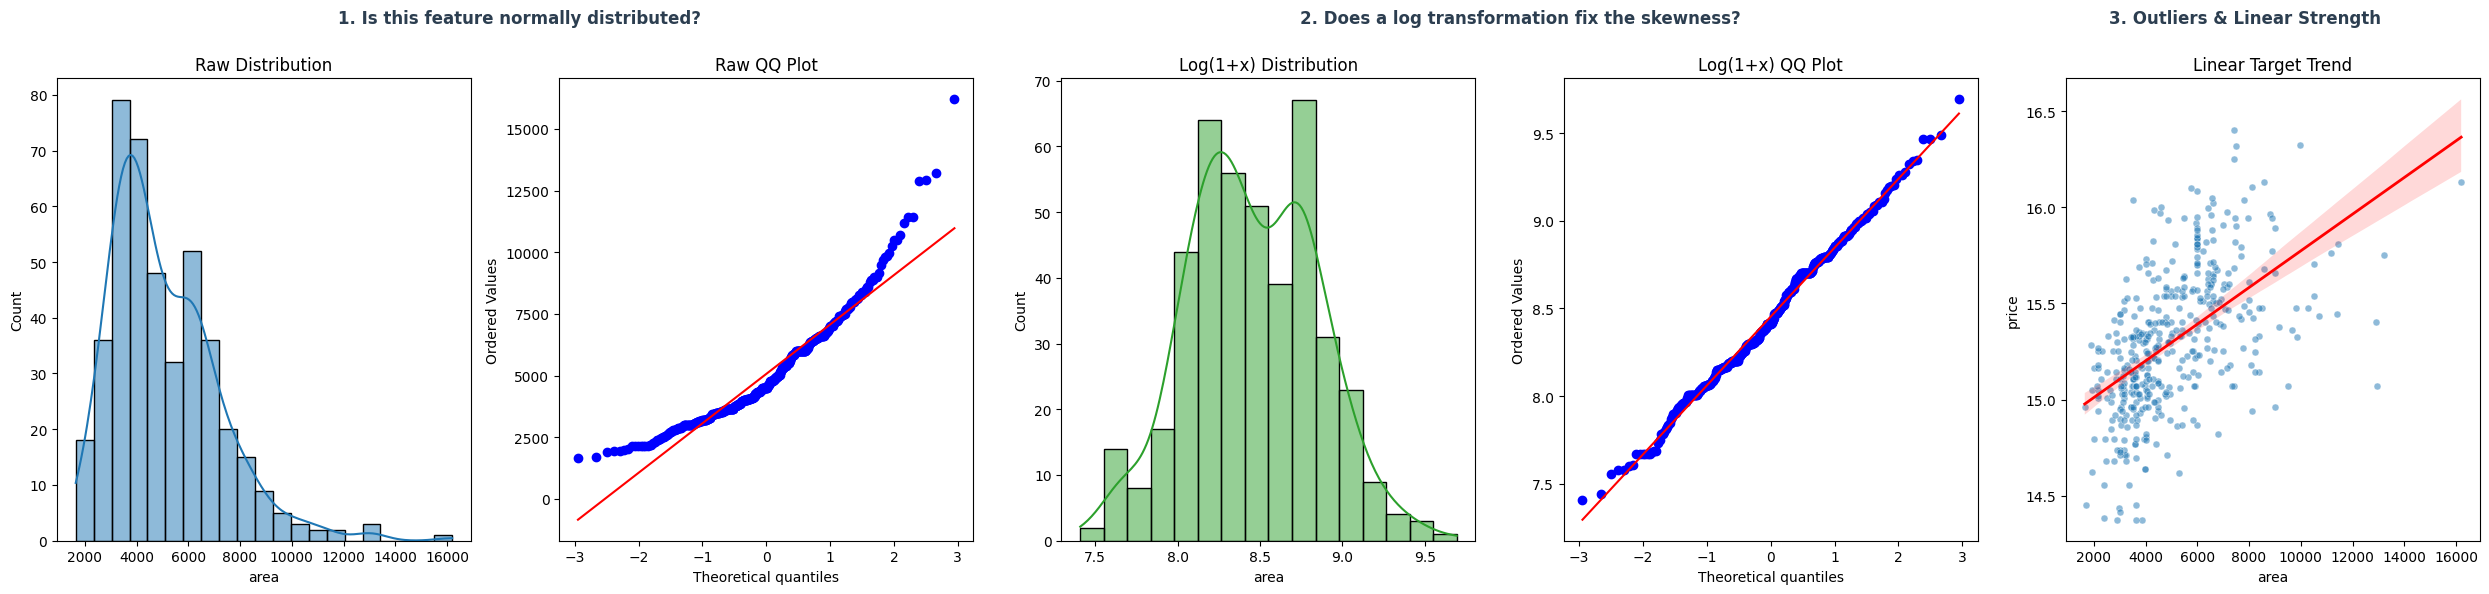

In [17]:
plot_features_against_target(df_train, ['area'], TARGET_NAME, None)

In [18]:
df_train.loc[:, 'area'] = np.log1p(df_train['area'])
df_test.loc[:, 'area'] = np.log1p(df_test['area'])

In [19]:
X_train = df_train.drop(columns=[TARGET_NAME])
X_test = df_test.drop(columns=[TARGET_NAME])

# create and fit the scaler on TRAINING numerical data
scaler = StandardScaler().fit(X_train)

# transform the data
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index) # <--- .transform() strips away the index column + it doesn't return column names!
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 2. Safely combine features and target (Indices match perfectly)
df_train_processed = pd.concat([X_train_scaled, df_train[[TARGET_NAME]]], axis=1)
df_test_processed = pd.concat([X_test_scaled, df_test[[TARGET_NAME]]], axis=1)

display(X_train_scaled.head())
display(X_test_scaled.head())

,area,bedrooms,bathrooms
138,0.164113,0.084228,-0.567518
80,0.629346,0.084228,-0.567518
358,-0.760589,-1.266538,-0.567518
132,0.264192,0.084228,-0.567518
98,0.872556,0.084228,1.514983


,area,bedrooms,bathrooms
138,0.164113,0.084228,-0.567518
80,0.629346,0.084228,-0.567518
358,-0.760589,-1.266538,-0.567518
132,0.264192,0.084228,-0.567518
98,0.872556,0.084228,1.514983


In [20]:
joblib.dump(scaler, 'std_scaler.joblib')
df_train_processed.to_csv(Path('data') / '3 train_post_EDA.csv', index=False)
df_test_processed.to_csv(Path('data') / '3 test_post_EDA.csv', index=False)